# SSM-2 — Selectivity (Mamba / S6)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/state-space-models/ssm2-selectivity.ipynb)

**The question:** what breaks when the recurrence cannot choose what to remember?

Prerequisites: [SSM-1](ssm1-linear-state-space.ipynb), [M3](../../foundations/m3-linear-attention.ipynb), [M7](../../foundations/m7-three-dials.ipynb).

The linear state-space model built a memory with a fixed decay. Its recurrence $h_t=\bar A h_{t-1}+\bar B x_t$ uses the same $\bar A,\bar B,C$ at every step, which is exactly what let the whole sequence collapse into one convolution kernel,

$$\bar K_\ell=C\bar A^\ell\bar B.$$

That fixed kernel is also the ceiling. Because $\bar A$ is the same at every step, the memory applies one decay to a token that matters and to filler alike, and it has no way to hold onto the first while letting the second pass. This module is Mamba's answer: let the step size and the input and output maps depend on the current token, so the gate can open on content the model should keep and stay shut on content it should drop. The move turns the gate dial from fixed-structured to input-dependent, and the bill it pays is the convolution the linear SSM relied on.

> Grounding: [Mamba](https://arxiv.org/abs/2312.00752) (Gu & Dao, 2023) §3.2 for the selection mechanism and Algorithm 2, §3.5.2 for the interpretation of $\Delta$, and §2 (Eqs. 1–4) for the discretization and the LTI convolution that selectivity breaks. Equations are cited by section, equation, or algorithm; anything I derive myself is marked as mine.

## Objective

After this module you should be able to:

- Explain why a linear time-invariant (LTI) SSM cannot select by content: its kernel $\bar K_\ell=C\bar A^\ell\bar B$ depends on the lag $\ell$ alone, so a past token is weighted by how long ago it arrived and never by what it is (Mamba §3.1).
- Write Mamba's selection mechanism: make $\Delta_t, B_t, C_t$ functions of the input while $A$ stays a learned parameter, with $\Delta_t=\operatorname{softplus}(\text{param}+s_\Delta(x_t))$ and $\bar A_t=\exp(\Delta_t A)$ (Mamba §3.2, Algorithm 2, Eq. 4).
- Read $\Delta_t$ as the learned gate and step size: a large $\Delta_t$ closes the retention and writes the current token, a small $\Delta_t$ holds the state and ignores it (Mamba §3.5.2).
- Say why input-dependent parameters make the recurrence time-varying, which removes the single global convolution and forces a scan (Mamba §3.2; [the parallel-scan aside](ssm2-aside-parallel-scan.ipynb)).
- State the module's dial setting: an additive write with the gate $\alpha_t=\bar A_t$ turned from fixed-structured (SSM-1) to input-dependent and channel-wise (M7 §2).

## Why it exists (the limitation it removes)

The linear state-space model's memory has a fixed decay, set once by $A$ and the step size $\Delta$ and held constant for the whole sequence. That constancy is the property Mamba calls linear time invariance (Mamba §2): the parameters $(\Delta, A, B, C)$, and with them $(\bar A, \bar B)$, are the same at every step. LTI is what buys the convolution, because the per-lag weight $\bar K_\ell=C\bar A^\ell\bar B$ does not depend on position, so one kernel covers the whole sequence and training runs by FFT (SSM-1 §3).

The same constancy caps what the memory can do. A model that applies one fixed decay to every token cannot look at a token and decide to keep it, or look at filler and decide to drop it, because the decision would have to change $\bar A$ from step to step and $\bar A$ is fixed. Mamba names the two tasks that expose this (Mamba §3.1). In **selective copying**, the tokens to remember sit at positions that vary from sequence to sequence, so a fixed lag-weighting cannot track them. In **induction heads**, the model must recall a value cued by content. An LTI SSM solves the plain copying task, where the spacing is fixed, and fails these, where it is not.

The fix is to give up time invariance on purpose. Make the step size $\Delta_t$ and the input and output maps $B_t, C_t$ depend on the current token, so the gate $\bar A_t=\exp(\Delta_t A)$ can differ from step to step according to content. In the master recurrence's terms this is one dial: keep the additive write, and turn the gate $\alpha_t=\bar A_t$ from its fixed-structured value to an input-dependent, channel-wise one (M7 §2's "input-dependent" gate). What it costs is the subject of §3.

### Reading

- [Mamba](https://arxiv.org/abs/2312.00752) (Gu & Dao, 2023): §3.1 — the selective-copying and induction-head tasks and why LTI models fail them; §3.2 — the selection mechanism (Algorithm 2; $s_B(x)=\operatorname{Linear}_N(x)$, $s_C(x)=\operatorname{Linear}_N(x)$, $s_\Delta(x)=\operatorname{Broadcast}_D(\operatorname{Linear}_1(x))$, $\tau_\Delta=\operatorname{softplus}$); §2 Eq. 4 — the ZOH discretization $\bar A=\exp(\Delta A)$; §3.3 — why the time-varying model needs a scan; §3.5.1–3.5.2 — Theorem 1's gated-recurrence connection and the interpretation of $\Delta$. The grounding source; every equation below is cited to it.

## 1. A fixed SSM has a content-agnostic kernel

Unrolling the linear SSM's recurrence gave a single kernel (SSM-1 §3): the output is $y_t=\sum_{\ell}\bar K_\ell\,x_{t-\ell}$ with $\bar K_\ell=C\bar A^\ell\bar B$ (Mamba Eq. 3a). Read the kernel as a schedule of weights, where the token that arrived $\ell$ steps ago contributes with weight $\bar K_\ell$. That weight is a function of the lag $\ell$ and nothing else. It does not see the token's value, so it cannot give a token that matters a larger weight than filler sitting at the same distance.

The consequence is that the memory prefers by recency and never by content. Drop the same salient value at an early position or a late one, and the late copy comes out larger for the single reason that it is closer to the read, weighted by $\bar A^{\text{lag}}$. Mamba states the failure directly: an LTI model's constant dynamics "cannot let them select the correct information from their context," and on the convolutional side the varying spacing between the relevant inputs and the output "cannot be modeled by static convolution kernels" (Mamba §3.1). The cell builds the fixed kernel and shows the recency-only preference.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

def discretize(A, B, dt):
    # ZOH, diagonal case (Mamba Eq. 4): Abar = exp(dt*A), Bbar = (exp(dt*A)-1)/A * B
    Abar = torch.exp(dt * A)
    Bbar = (Abar - 1.0) / A * B
    return Abar, Bbar

def run_recurrence(Abar, Bbar, C, x):
    # SSM-1's LTI recurrence: h_t = Abar h_{t-1} + Bbar x_t ;  y_t = C h_t
    h = torch.zeros(Abar.shape[0])
    out = []
    for xt in x:
        h = Abar * h + Bbar * xt
        out.append((C * h).sum())
    return torch.stack(out)

# One real diagonal mode: N=1, A=-1 -- Mamba's Theorem 1 setting, so the gate stays legible.
A = torch.tensor([-1.0])
B = torch.tensor([1.0])
C = torch.tensor([1.0])

L, dt = 40, 0.1                                    # a fixed step size -> a fixed, slow kernel
Abar, Bbar = discretize(A, B, dt)
kernel = torch.stack([(C * Abar ** l * Bbar).sum() for l in torch.arange(L)])   # Kbar_l = C Abar^l Bbar
print("the fixed kernel weights a past token by its LAG alone (Mamba Eq. 3a):")
print("  Kbar[:6] =", [f"{v:.3f}" for v in kernel[:6].tolist()])

# the same salient value at an early vs a late position: the late one wins on recency, not content
x_early = torch.zeros(L); x_early[5]  = 1.0
x_late  = torch.zeros(L); x_late[25]  = 1.0
r_early = run_recurrence(Abar, Bbar, C, x_early)[-1]
r_late  = run_recurrence(Abar, Bbar, C, x_late)[-1]
print(f"recall of the same marker at position  5 : {r_early.item():.4f}")
print(f"recall of the same marker at position 25 : {r_late.item():.4f}")
print(f"ratio = {(r_late / r_early).item():.3f}  ==  Abar^-(25-5) = {(Abar ** -20).item():.3f}  (pure recency, not content)")

the fixed kernel weights a past token by its LAG alone (Mamba Eq. 3a):
  Kbar[:6] = ['0.095', '0.086', '0.078', '0.070', '0.064', '0.058']
recall of the same marker at position  5 : 0.0032
recall of the same marker at position 25 : 0.0235
ratio = 7.389  ==  Abar^-(25-5) = 7.389  (pure recency, not content)


The kernel is a fixed, monotone decay, so the weight on a past token is set entirely by its lag. The two recalls make it concrete: the marker at the later position comes back larger than the identical marker at the earlier one, and the ratio between them is exactly $\bar A$ raised to the gap in their positions, with nothing about content entering. A memory whose only knob is "how long ago" cannot implement "this one is worth keeping." Selectivity turns that knob into something the token itself can set.

## 2. The fix: make $\Delta$, $B$, and $C$ input-dependent

Mamba's change is small to state. Take the four parameters of the SSM and let three of them become functions of the current token (Mamba §3.2, Algorithm 2):

$$B_t=s_B(x_t),\qquad C_t=s_C(x_t),\qquad \Delta_t=\operatorname{softplus}\big(\text{param}+s_\Delta(x_t)\big),$$

Here $s_B$ and $s_C$ are learned linear maps into the state dimension and $s_\Delta$ a learned scalar projection broadcast over channels (Mamba §3.2). The state matrix $A$ stays a plain learned parameter. Mamba's reason for leaving $A$ alone is that it reaches the recurrence only through $\bar A_t=\exp(\Delta_t A)$, so making $\Delta_t$ selective already makes the effective transition $\bar A_t$ selective, and a separate selection on $A$ would be redundant (Mamba §3.5.2).

The load-bearing parameter is $\Delta_t$. Discretization turns it into the gate, for a diagonal mode $a$ (Mamba Eq. 4, reduced to one channel as in SSM-1 §2):

$$\bar A_t=\exp(\Delta_t A),\qquad \bar B_t=\frac{\exp(\Delta_t a)-1}{a}\,B_t.$$

With $A$ stable ($\operatorname{Re}(a)<0$), a large $\Delta_t$ sends $\bar A_t$ toward $0$ and $\bar B_t$ toward a full write, so the step wipes the old state and stores the current token. A small $\Delta_t$ sends $\bar A_t$ toward $1$ and $\bar B_t$ toward $0$, so the state persists and the token is ignored. Mamba reads it the same way: "a large $\Delta$ resets the state $h$ and focuses on the current input $x$, while a small $\Delta$ persists the state and ignores the current input" (Mamba §3.5.2). At $A=-1$ with a single mode this is exactly a gate, $h_t=(1-g_t)h_{t-1}+g_t x_t$ with $g_t=1-\exp(-\Delta_t)$, which is Mamba's Theorem 1. Since $1-\exp(-\operatorname{softplus}(z))=\sigma(z)$, that gate is a sigmoid of the input: the same gate M4 used to fade its memory, and the one inside every LSTM and GRU.

The demo hand-sets $s_\Delta$ to read a marker channel: a token flagged as content gets a large $\Delta_t$, filler gets a small one. Real Mamba learns this detector from the token; wiring it by hand isolates the mechanism, which is the point of the toy. The cell prints the gate on a marker and on filler.

the gate opens and closes by content (A = -1):
   token   Delta_t    Abar_t    Bbar_t
  filler     0.001     0.999     0.001
  marker     5.007     0.007     0.993


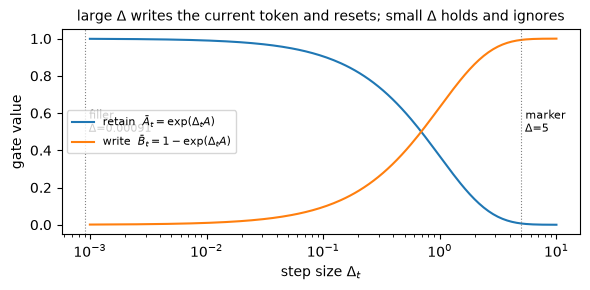

small Delta: Abar->1, Bbar->0 (persist, ignore).  large Delta: Abar->0, Bbar->1 (reset, write).


In [2]:
import torch.nn.functional as F

# Selection: Delta_t = softplus(param + s_Delta(x_t)). Here s_Delta reads a marker channel
# (large Delta on content, small on filler), hand-wired to isolate the gate; Mamba learns it.
def delta_of(marker, w=12.0, b=-7.0):
    return F.softplus(b + w * marker)              # Mamba: tau_Delta = softplus (section 3.2)

print("the gate opens and closes by content (A = -1):")
print(f"{'token':>8}  {'Delta_t':>8}  {'Abar_t':>8}  {'Bbar_t':>8}")
for name, mk in [("filler", 0.0), ("marker", 1.0)]:
    d = delta_of(torch.tensor(mk))
    Ab, Bb = torch.exp(d * A), (torch.exp(d * A) - 1.0) / A * B
    print(f"{name:>8}  {d.item():8.3f}  {Ab.item():8.3f}  {Bb.item():8.3f}")

# the retain/write curves as functions of Delta, with the two operating points marked
dd = torch.logspace(-3, 1, 200)
retain = torch.exp(dd * A[0])                       # Abar = exp(Delta * A)
write  = 1.0 - torch.exp(dd * A[0])                 # Bbar = 1 - exp(Delta*A) at A=-1,B=1 (Theorem 1's g)
plt.figure(figsize=(6, 3))
plt.plot(dd, retain, label=r"retain  $\bar A_t=\exp(\Delta_t A)$")
plt.plot(dd, write,  label=r"write  $\bar B_t=1-\exp(\Delta_t A)$")
for name, mk in [("filler", 0.0), ("marker", 1.0)]:
    dv = delta_of(torch.tensor(mk)).item()
    plt.axvline(dv, color="gray", ls=":", lw=0.8)
    plt.text(dv, 0.55, f" {name}\n $\\Delta$={dv:.2g}", fontsize=8, va="center")
plt.xscale("log"); plt.xlabel(r"step size $\Delta_t$"); plt.ylabel("gate value")
plt.title(r"large $\Delta$ writes the current token and resets; small $\Delta$ holds and ignores", fontsize=10)
plt.legend(fontsize=8, loc="center left"); plt.tight_layout(); plt.show()
print("small Delta: Abar->1, Bbar->0 (persist, ignore).  large Delta: Abar->0, Bbar->1 (reset, write).")

The two rows are the gate opening and closing by content. On the marker the step size is large, the retention $\bar A_t$ collapses to near zero and the write $\bar B_t$ is near one, so the token is stored and the previous state cleared. On filler the step size is tiny, $\bar A_t$ sits just below one and $\bar B_t$ is near zero, so the state holds and the filler barely enters. The retain and write curves cross exactly as Theorem 1's gate $g_t=1-\exp(-\Delta_t)$ predicts, which is what makes $\Delta_t$ a single focus control the token sets: opening the write and closing the memory are the same motion.

::: {.callout-note collapse="true"}
## Q: Why not make $A$ input-dependent too, if selection is the goal?

You could, and Mamba discusses it (§3.5.2). The reason it does not is that $A$ influences the recurrence only through the discretized transition $\bar A_t=\exp(\Delta_t A)$. Since $\Delta_t$ is already input-dependent, $\bar A_t$ is already input-dependent, so a token can already set its own effective decay through $\Delta_t$. Selecting on $A$ as well would add parameters without adding reach: "selectivity in $\Delta$ is enough to ensure selectivity in $(\bar A, \bar B)$, and is the main source of improvement" (Mamba §3.5.2).

The division of labor is that $A$ carries the fixed structure that makes the mode a stable memory (the S4 and S4D content of SSM-1), and $\Delta_t$ carries the per-token decision of how much of that memory to spend on this token. Making $B_t$ and $C_t$ selective adds finer control on top: $B_t$ sets how much of the token enters the state, $C_t$ how much of the state reaches the output, which Mamba reads as gating on content and on context respectively (Mamba §3.5.2).
:::

## 3. The cost: no single convolution, so you scan

The convolution existed because the kernel weight $\bar K_\ell=C\bar A^\ell\bar B$ depended on the lag alone. Once $\Delta_t, B_t, C_t$ vary with the input, the weight linking a past token at position $j$ to the output at position $t$ becomes

$$W_{t,j}=C_t\Big(\textstyle\prod_{k=j+1}^{t}\bar A_k\Big)\bar B_j,$$

a product of the specific gates at the steps in between (my expansion of Algorithm 2's time-varying recurrence). Two positions the same distance apart no longer share a weight, because the tokens between them differ. The parameters are now time-varying, so there is no single kernel to convolve.

The clean way to see it is to read $W$ as a matrix. For an LTI SSM $W_{t,j}$ depends only on $t-j$, so $W$ is constant along each diagonal, which is the definition of a convolution (a Toeplitz operator). For the selective SSM the diagonals are no longer constant, so no convolution reproduces it. What still works is to roll the recurrence forward one step at a time, carrying the state, which is a scan (Mamba Algorithm 2 labels the selective model "time-varying: recurrence (scan) only"). A naive scan is sequential and would give up the parallel training the convolution bought; recovering it takes an associative parallel scan, the subject of [the parallel-scan aside](ssm2-aside-parallel-scan.ipynb). The cell builds $W$ both ways and checks which one is Toeplitz.

deviation from a convolution (how far the diagonals are from constant):
  LTI (constant Delta): 7.45e-09   -> Toeplitz, one kernel
  selective           : 0.910   -> not Toeplitz, no single kernel


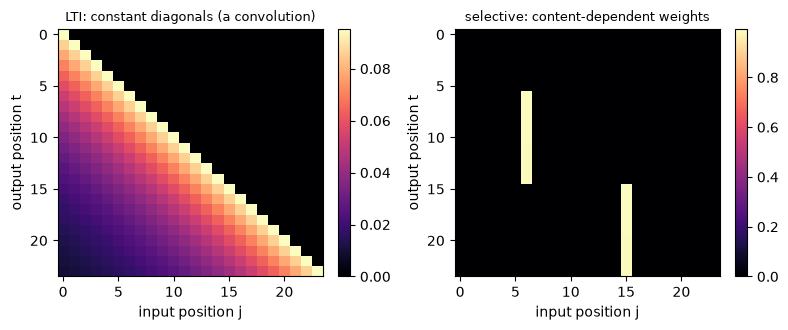

marked positions (6, 15) write strongly and are held forward, breaking the diagonal structure.


In [3]:
def selective_scan(A, x, delta, B_seq, C_seq):
    # time-varying recurrence (Mamba Algorithm 2). delta:(L,), B_seq,C_seq:(L,N).
    # returns y:(L,) and the per-step gates for inspection.
    h = torch.zeros(A.shape[0])
    ys, Abars, Bbars = [], [], []
    for t in range(x.shape[0]):
        Ab = torch.exp(delta[t] * A)               # Abar_t = exp(Delta_t A): now varies with t
        Bb = (Ab - 1.0) / A * B_seq[t]
        h = Ab * h + Bb * x[t]
        ys.append((C_seq[t] * h).sum()); Abars.append(Ab); Bbars.append(Bb)
    return torch.stack(ys), torch.stack(Abars), torch.stack(Bbars)

def influence_matrix(Abars, Bbars, C_seq):
    # W[t,j] = C_t (prod_{k=j+1..t} Abar_k) Bbar_j : weight of input j on output t (N=1)
    a, b, c = Abars[:, 0], Bbars[:, 0], C_seq[:, 0]
    Lx = a.shape[0]
    W = torch.zeros(Lx, Lx)
    for t in range(Lx):
        for j in range(t + 1):
            W[t, j] = c[t] * (torch.prod(a[j + 1:t + 1]) if t > j else torch.tensor(1.0)) * b[j]
    return W

def toeplitz_dev(W):
    # a convolution has constant diagonals; measure the largest spread within any diagonal
    Lx = W.shape[0]; dev = 0.0
    for d in range(Lx):
        diag = torch.stack([W[j + d, j] for j in range(Lx - d)])
        dev = max(dev, (diag - diag.mean()).abs().max().item())
    return dev

Ls = 24
marker = torch.zeros(Ls); marker[[6, 15]] = 1.0
xs = torch.randn(Ls)
Bs, Cs = B.repeat(Ls, 1), C.repeat(Ls, 1)
_, Ab_lti, Bb_lti = selective_scan(A, xs, torch.full((Ls,), dt), Bs, Cs)     # constant Delta -> LTI
_, Ab_sel, Bb_sel = selective_scan(A, xs, delta_of(marker),      Bs, Cs)     # selective Delta
W_lti, W_sel = influence_matrix(Ab_lti, Bb_lti, Cs), influence_matrix(Ab_sel, Bb_sel, Cs)
print("deviation from a convolution (how far the diagonals are from constant):")
print(f"  LTI (constant Delta): {toeplitz_dev(W_lti):.2e}   -> Toeplitz, one kernel")
print(f"  selective           : {toeplitz_dev(W_sel):.3f}   -> not Toeplitz, no single kernel")

fig, ax = plt.subplots(1, 2, figsize=(8, 3.4))
for a_, W, ttl in [(ax[0], W_lti, "LTI: constant diagonals (a convolution)"),
                   (ax[1], W_sel, "selective: content-dependent weights")]:
    im = a_.imshow(W, aspect="auto", cmap="magma"); a_.set_title(ttl, fontsize=9)
    a_.set_xlabel("input position j"); a_.set_ylabel("output position t")
    fig.colorbar(im, ax=a_, fraction=0.046)
plt.tight_layout(); plt.show()
print("marked positions (6, 15) write strongly and are held forward, breaking the diagonal structure.")

The LTI influence matrix is constant along its diagonals to floating-point tolerance, the signature of a single kernel sliding over the sequence. The selective matrix is not: the columns at the marked positions write strongly and the held state carries them forward, so the weight between two positions depends on what sits between them, and the diagonals vary. The heatmaps show the same thing by eye, with clean stripes on the left and an irregular pattern on the right. This is what "selectivity breaks the LTI convolution" means in one picture, and it is why the hardware-aware scan the rest of Mamba is built around exists at all.

::: {.callout-note collapse="true"}
## Q: If selectivity kills the convolution, isn't Mamba slower than S4?

In raw arithmetic the selective scan does more work than a fixed convolution, and a naive version that writes the full state to memory at every step would indeed be slow. Mamba's answer is not to restore the convolution but to make the scan cheap where it actually costs, which is memory bandwidth. Its selective scan is a hardware-aware kernel that keeps the expanded state in fast SRAM, runs the recurrence there, and never materializes the state in slow HBM (Mamba §3.3). The recurrence is also associative, so it parallelizes over the sequence in $O(\log T)$ depth instead of running strictly left to right. Both points are the subject of [the parallel-scan aside](ssm2-aside-parallel-scan.ipynb); the toy here uses a plain Python scan and makes no efficiency claim.
:::

## 4. The toy: selective copying

Now run the two models on the task the fixed kernel cannot do. Each sequence is a stream of filler values with one marked token dropped at a random position; the marker carries a payload, and the job is to report that payload at the end, ignoring the filler before and after it. The marker position varies from sequence to sequence, which is the exact difficulty Mamba's selective-copying task is built around (Mamba §3.1): a fixed lag-weighting cannot track a target that moves.

The one thing that differs between the two models is the gate. The selective model sets $\Delta_t$ from the marker channel, large on the marker and small on filler, so it writes the payload when it appears and holds it through the filler. The LTI model uses a constant $\Delta$; to be fair it is given its best constant, chosen by a small search, and both models get the same closed-form gain on the readout so each is judged at its best. The cell prints the recall error for both and plots the recovered payload against the true one.

L= 16   selective err = 0.005    LTI (best constant Delta) err = 0.966


L= 32   selective err = 0.009    LTI (best constant Delta) err = 0.973


L= 48   selective err = 0.012    LTI (best constant Delta) err = 0.988


L= 64   selective err = 0.019    LTI (best constant Delta) err = 0.992


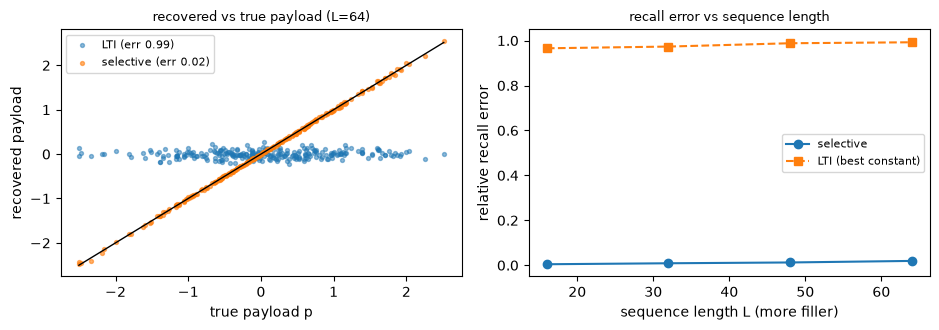

selective: writes on the marker, holds through filler -> error stays low as L grows.
LTI: no constant step (best here Delta=0.02) both writes the payload and ignores filler -> error near 1.


In [4]:
def make_batch(L, n, gen):
    # one marked token per sequence at a random position, carrying a random payload; rest is filler
    x = torch.randn(n, L, generator=gen)
    p = torch.randn(n, generator=gen)
    pos = torch.randint(0, L, (n,), generator=gen)
    m = torch.zeros(n, L)
    for i in range(n):
        m[i, pos[i]] = 1.0
        x[i, pos[i]] = p[i]
    return x, m, p

def recall(x, m, selective, const_dt):
    n, L = x.shape
    Bs, Cs = B.repeat(L, 1), C.repeat(L, 1)
    out = torch.zeros(n)
    for i in range(n):
        d = delta_of(m[i]) if selective else torch.full((L,), const_dt)
        out[i] = selective_scan(A, x[i], d, Bs, Cs)[0][-1]
    return out

def recall_err(phat, p):
    g = (phat @ p) / (phat @ phat + 1e-9)              # best scalar readout gain (fair to both models)
    return ((g * phat - p).norm() / p.norm()).item()

gen = torch.Generator().manual_seed(7)
grid = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 4.0]      # candidate constant step sizes for the LTI baseline
Ls_task = [16, 32, 48, 64]
err_sel, err_lti = [], []
for Lt in Ls_task:
    x, m, p = make_batch(Lt, 256, gen)
    err_sel.append(recall_err(recall(x, m, True, 0.0), p))
    err_lti.append(min(recall_err(recall(x, m, False, cd), p) for cd in grid))    # LTI at its best constant
    print(f"L={Lt:3d}   selective err = {err_sel[-1]:.3f}    LTI (best constant Delta) err = {err_lti[-1]:.3f}")

x, m, p = make_batch(64, 256, gen)
best_cd = min(grid, key=lambda cd: recall_err(recall(x, m, False, cd), p))
ph_sel, ph_lti = recall(x, m, True, 0.0), recall(x, m, False, best_cd)
gs = (ph_sel @ p) / (ph_sel @ ph_sel); gl = (ph_lti @ p) / (ph_lti @ ph_lti)
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))
ax[0].scatter(p, gl * ph_lti, s=8, alpha=0.5, label=f"LTI (err {err_lti[-1]:.2f})")
ax[0].scatter(p, gs * ph_sel, s=8, alpha=0.6, label=f"selective (err {err_sel[-1]:.2f})")
lim = [p.min().item(), p.max().item()]
ax[0].plot(lim, lim, "k", lw=1); ax[0].set_title("recovered vs true payload (L=64)", fontsize=9)
ax[0].set_xlabel("true payload p"); ax[0].set_ylabel("recovered payload"); ax[0].legend(fontsize=8)
ax[1].plot(Ls_task, err_sel, "o-", label="selective")
ax[1].plot(Ls_task, err_lti, "s--", label="LTI (best constant)")
ax[1].set_title("recall error vs sequence length", fontsize=9)
ax[1].set_xlabel("sequence length L (more filler)"); ax[1].set_ylabel("relative recall error")
ax[1].set_ylim(-0.05, 1.05); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("selective: writes on the marker, holds through filler -> error stays low as L grows.")
print(f"LTI: no constant step (best here Delta={best_cd}) both writes the payload and ignores filler -> error near 1.")

The selective model recovers the payload almost exactly and stays accurate as the filler grows, because it writes on the marker and then holds, so the length of the gauntlet barely matters. The LTI model cannot get near it at any constant step size. A large step writes the payload but forgets it within a few filler tokens; a small step holds but never writes the payload strongly and lets the accumulated filler bury it. Its best constant is a compromise that fails both ways, and the error rises as the sequence lengthens because there is more filler to average in. The scatter shows it directly, a tight line on $y=x$ for the selective model and a diffuse cloud for the fixed one.

One more check ties the selective implementation back to the linear SSM. The selective scan is a strict generalization of the LTI recurrence: turn off the input-dependence, holding $\Delta$, $B$, and $C$ constant, and it must compute the identical function the linear SSM computed. This is an exact identity, so it is an assertion rather than a plot.

In [5]:
# With input-dependence OFF (constant Delta, B, C) the selective scan must reduce to
# SSM-1's LTI recurrence, exactly. An identity, so it is an assert.
xa = torch.randn(50)
La = xa.shape[0]
y_lti = run_recurrence(*discretize(A, B, dt), C, xa)                            # SSM-1's recurrence
y_sel = selective_scan(A, xa, torch.full((La,), dt), B.repeat(La, 1), C.repeat(La, 1))[0]
print("max |selective_scan(const) - SSM-1 recurrence| =", f"{(y_sel - y_lti).abs().max().item():.2e}")
assert torch.allclose(y_sel, y_lti, atol=1e-6)
print("torch.allclose -> True: with input-dependence OFF, the selective scan is exactly SSM-1's LTI SSM.")

max |selective_scan(const) - SSM-1 recurrence| = 0.00e+00
torch.allclose -> True: with input-dependence OFF, the selective scan is exactly SSM-1's LTI SSM.


The two outputs agree to floating-point tolerance, so the selective scan contains the LTI SSM as the special case where nothing depends on the input. Selectivity is a setting of this one recurrence.

**Scope.** This is a mechanism demo at the smallest scale that shows the effect. The state is a single real diagonal mode ($N=1$, $A=-1$), Mamba's Theorem 1 setting, which keeps the gate legible but sits far below the diagonal state of a real Mamba block and holds only one scalar, so the toy shows selecting one token rather than copying many in order. The selection function is hand-wired to a marker channel instead of learned from the token, which isolates the gate at the cost of not testing whether the detector is learnable (in the paper it is). And the scan is a plain Python loop with no hardware-aware kernel, so it settles what selectivity computes and leaves how Mamba makes it fast to [the parallel-scan aside](ssm2-aside-parallel-scan.ipynb). What the toy does settle is the module's one claim: with the state size and the write held fixed, letting the gate depend on content is what lets the memory keep a token that matters and ignore the filler around it, which a fixed gate cannot do at any constant step size.

## Exit check

Ready for SSM-3 when you can:

1. Explain why an LTI SSM cannot select by content: the kernel $\bar K_\ell=C\bar A^\ell\bar B$ weights a past token by its lag alone, so it prefers by recency and has no knob for "this token matters."
2. Write Mamba's selection mechanism: $B_t=s_B(x_t)$, $C_t=s_C(x_t)$, $\Delta_t=\operatorname{softplus}(\text{param}+s_\Delta(x_t))$, with $A$ left a parameter, and say why $A$ need not be selective.
3. Read $\Delta_t$ through $\bar A_t=\exp(\Delta_t A)$: a large $\Delta_t$ resets the state and writes the current token, a small $\Delta_t$ holds the state and ignores it, which at $A=-1$ is Theorem 1's gate.
4. Say why input-dependent parameters remove the single convolution (the influence matrix stops being Toeplitz) and force a scan.
5. State the dial setting: an additive write with the gate $\alpha_t=\bar A_t$ turned from fixed-structured to input-dependent and channel-wise, and name a task a fixed gate cannot do.

**Next →** [SSM-3 — Mamba-2 and the duality](ssm3-mamba2-ssd.ipynb). Selectivity bought content-based memory at the price of the convolution. SSM-3 restricts the gate to a scalar per head and finds the recurrence turning back into an attention matrix, which is where the SSM line rejoins linear attention.